# Decision Tree Classifier

## Objective

The objective of this experiment is to train a Decision Tree classifier on the Titanic dataset and compare its performance with the Logistic Regression model.

In this experiment, we will evaluate the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

##Loading Dataset

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Check dataset information
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#Data Preprocessing
Missing values are handled and categorical variables are converted into numerical format.

In [6]:
f = pd.read_csv("Titanic-Dataset.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


### Encoding Categorical Variables

Machine learning algorithms cannot directly process text values.

Therefore, categorical features are converted into numerical representation using one-hot encoding.

In [7]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,"Name_Abbott, Mr. Rossmore Edward",...,Cabin_E8,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T
0,1,0,3,0,22.0,1,0,7.2500,0,False,...,False,False,False,False,False,False,False,False,False,False
1,2,1,1,1,38.0,1,0,71.2833,1,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,1,26.0,0,0,7.9250,0,False,...,False,False,False,False,False,False,False,False,False,False
3,4,1,1,1,35.0,1,0,53.1000,0,False,...,False,False,False,False,False,False,False,False,False,False
4,5,0,3,0,35.0,0,0,8.0500,0,False,...,False,False,False,False,False,False,False,False,False,False


## Preparing Data for Training

The dataset is divided into features and target variable.

Features contain information about passengers, while the target variable represents the survival outcome.

In [8]:
X = df[['Pclass','Sex','Age','Fare']]

y = df['Survived']

## Splitting the Dataset

To evaluate the model performance, the dataset is divided into training and testing parts.

The training data is used to build the model, while the testing data is used to evaluate how well the model performs on unseen data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
df[['Sex','Age','Fare']].isnull().sum()

,0
Sex,0
Age,0
Fare,0


##  Training the Decision Tree Model

A Decision Tree classifier is a supervised machine learning algorithm that makes decisions based on feature values.

Unlike Logistic Regression, Decision Tree can capture non-linear relationships between variables.

In [15]:
decision_tree = DecisionTreeClassifier(random_state=42)

##The model is trained using the training dataset.

During this process, the Decision Tree learns patterns between passenger characteristics and survival outcomes.

In [20]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Making Predictions

After training, the model is used to predict survival outcomes for passengers from the test dataset.

In [21]:
y_pred_tree = decision_tree.predict(X_test)

##Decision Tree Performance

In [26]:
Decision_Tree_accuracy = accuracy_score(y_test, y_pred_tree)
Decision_Tree_precision = precision_score(y_test, y_pred_tree)
Decision_Tree_recall = recall_score(y_test, y_pred_tree)
Decision_Tree_f1 = f1_score(y_test, y_pred_tree)


print("Accuracy:", round(Decision_Tree_accuracy, 3))
print("Precision:", round(Decision_Tree_precision, 3))
print("Recall:", round(Decision_Tree_recall, 3))
print("F1-score:", round(Decision_Tree_f1, 3))

Accuracy: 0.732
Precision: 0.662
Recall: 0.716
F1-score: 0.688


##Confusion Matrix
The confusion matrix provides a detailed overview of the model's predictions.

It shows how many passengers were correctly and incorrectly classified.

Unlike Accuracy, the confusion matrix helps identify specific types of errors, such as false positives and false negatives.

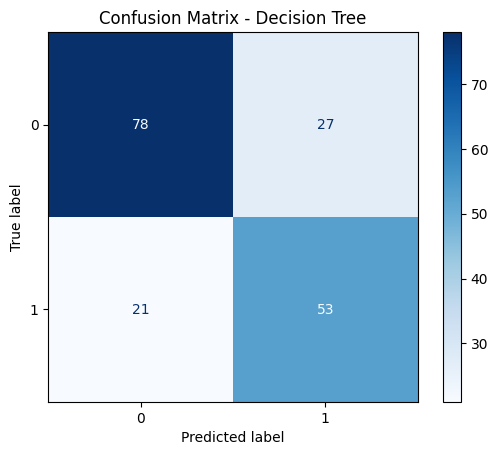

In [32]:
cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Model Performance Comparison

The performance of the Decision Tree classifier is compared with the Logistic Regression model from the previous experiment.

The comparison is based on Accuracy, Precision, Recall, and F1-score.          

In [31]:
comparison = pd.DataFrame({"Model": ["Decision Tree", "Logistic Regression"], "Accuracy": [0.732, 0.804], "Precision": [0.662, 0.783], "Recall": [0.716, 0.730], "F1-score": [0.688, 0.755]})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.732,0.662,0.716,0.688
1,Logistic Regression,0.804,0.783,0.730,0.755


In [33]:
matrix_table = pd.DataFrame({"Model":["Decision Tree", "Logistic Regression"],"True Negative": [78, 90],"False Positive": [27, 15],"False negative": [21, 20],"True Positive": [53, 54],})
matrix_table

,Model,True Negative,False Positive,False negative,True Positive
0,Decision Tree,78,27,21,53
1,Logistic Regression,90,15,20,54


# Analysis of Results

The results show that Logistic Regression achieved better performance compared to the Decision Tree classifier.

Logistic Regression obtained higher Accuracy (0.804) and F1-score (0.755), while Decision Tree showed lower performance.

The lower performance of Decision Tree may be caused by overfitting or the limited size of the dataset.

Although Decision Tree can capture complex relationships between features, Logistic Regression provided more stable predictions for this dataset.

The confusion matrix also shows that Logistic Regression made fewer classification errors, especially fewer False Positive predictions (15 compared to 27 for Decision Tree).

## Conclusion

In this experiment, the Decision Tree classifier was trained and compared with Logistic Regression using the Titanic dataset.

The results showed that Logistic Regression achieved better overall performance with higher Accuracy and F1-score.

This experiment demonstrates that a more complex model does not always provide better results, and model performance depends on the relationship between the algorithm and the dataset.